# Import Libraries

In [2]:
# =============================================
# NOTEBOOK 7: FINAL MODEL SAVING & SUMMARY
# EcoType - Forest Cover Type Prediction
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print(" All libraries imported successfully!")

 All libraries imported successfully!


# Load Everything

In [5]:
# Load dataset and all saved encoders

df = pd.read_csv('../data/forest_cover_engineered.csv')

# Load all encoders saved in Notebook 4
le_wilderness = joblib.load('../models/le_wilderness.pkl')
le_soil       = joblib.load('../models/le_soil.pkl')
le_target     = joblib.load('../models/le_target.pkl')

# Load the best model saved in Notebook 6
best_model = joblib.load('../models/best_model.pkl')

print(f" Dataset loaded! Shape: {df.shape}")
print(f" All encoders loaded!")
print(f" Best model loaded!")
print(f"\nModel type: {type(best_model).__name__}")

 Dataset loaded! Shape: (145890, 17)
 All encoders loaded!
 Best model loaded!

Model type: RandomForestClassifier


# Verify Encoders Work Correctly

In [8]:
# Let's verify our encoders are working properly

print("=== WILDERNESS AREA ENCODER ===")
print(f"Classes: {le_wilderness.classes_}")
print(f"Encoded: {le_wilderness.transform(le_wilderness.classes_)}")

print("\n=== SOIL TYPE ENCODER ===")
print(f"Number of soil types: {len(le_soil.classes_)}")
print(f"Classes: {le_soil.classes_}")

print("\n=== TARGET ENCODER ===")
print("Cover Type Mapping (number → forest name):")
for i, name in enumerate(le_target.classes_):
    print(f"  {i} → {name}")

=== WILDERNESS AREA ENCODER ===
Classes: [1 2 3 4]
Encoded: [0 1 2 3]

=== SOIL TYPE ENCODER ===
Number of soil types: 39
Classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]

=== TARGET ENCODER ===
Cover Type Mapping (number → forest name):
  0 → Aspen
  1 → Cottonwood/Willow
  2 → Douglas-fir
  3 → Krummholz
  4 → Lodgepole Pine
  5 → Ponderosa Pine
  6 → Spruce/Fir


# Prepare Final Test Data

In [11]:
# Prepare data one final time to get clean test results

X = df.drop(columns=['Cover_Type'])
y = df['Cover_Type']

# Balance classes
ros = RandomOverSampler(random_state=42)
X_balanced, y_balanced = ros.fit_resample(X, y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print(f" Final test data prepared!")
print(f"Test set size: {X_test.shape}")

 Final test data prepared!
Test set size: (144300, 16)


# Final Model Performance

In [14]:
# Get final predictions and show complete evaluation

y_pred = best_model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)

print("=" * 50)
print("      FINAL MODEL PERFORMANCE REPORT")
print("=" * 50)
print(f"\nModel:    Random Forest Classifier")
print(f"Accuracy: {final_acc*100:.2f}%")
print(f"\n=== CLASSIFICATION REPORT ===\n")

# Show forest names instead of numbers
target_names = le_target.classes_
print(classification_report(y_test, y_pred, 
                             target_names=target_names))

      FINAL MODEL PERFORMANCE REPORT

Model:    Random Forest Classifier
Accuracy: 99.63%

=== CLASSIFICATION REPORT ===

                   precision    recall  f1-score   support

            Aspen       1.00      1.00      1.00     20614
Cottonwood/Willow       1.00      1.00      1.00     20614
      Douglas-fir       1.00      1.00      1.00     20614
        Krummholz       1.00      1.00      1.00     20615
   Lodgepole Pine       1.00      0.98      0.99     20614
   Ponderosa Pine       1.00      1.00      1.00     20614
       Spruce/Fir       0.98      1.00      0.99     20615

         accuracy                           1.00    144300
        macro avg       1.00      1.00      1.00    144300
     weighted avg       1.00      1.00      1.00    144300



#  Final Confusion Matrix with Forest Names

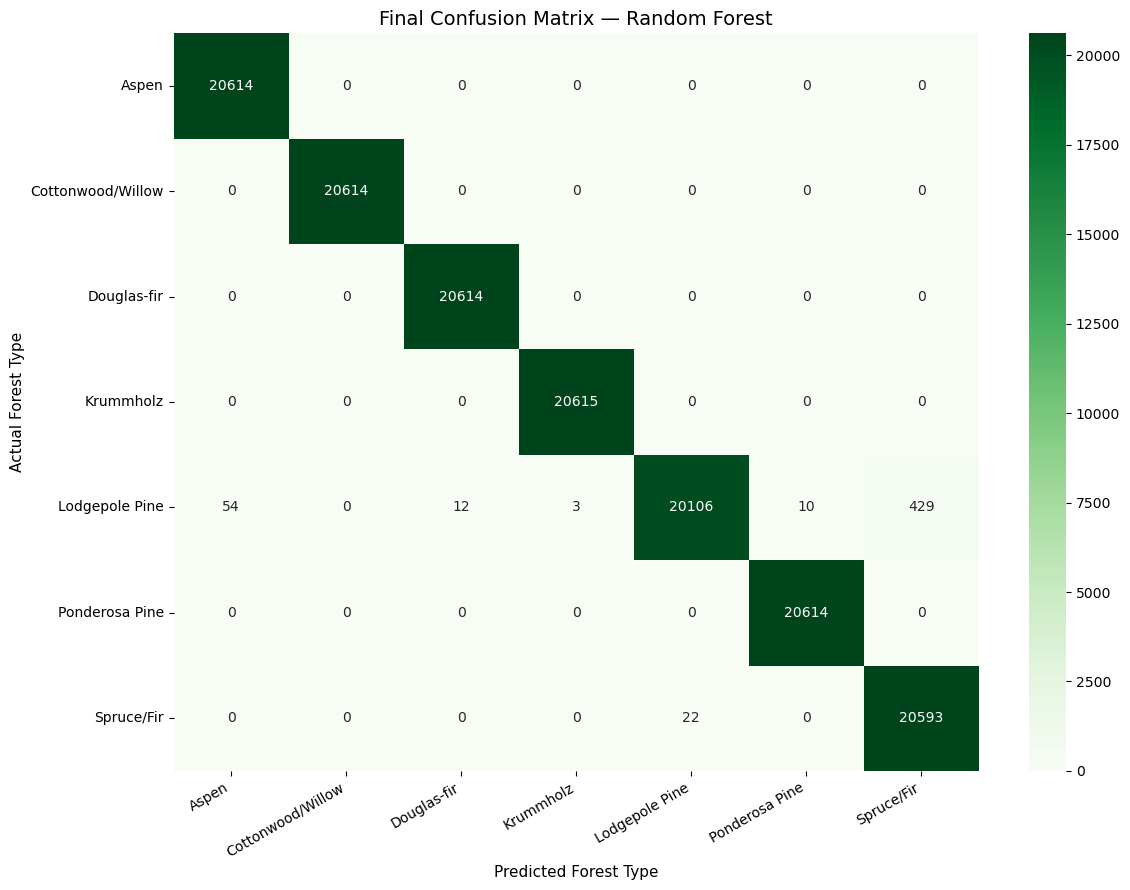

In [17]:
# Beautiful final confusion matrix with forest type names

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Greens',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)

plt.title('Final Confusion Matrix — Random Forest', fontsize=14)
plt.xlabel('Predicted Forest Type', fontsize=11)
plt.ylabel('Actual Forest Type', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Feature Importance Final Plot

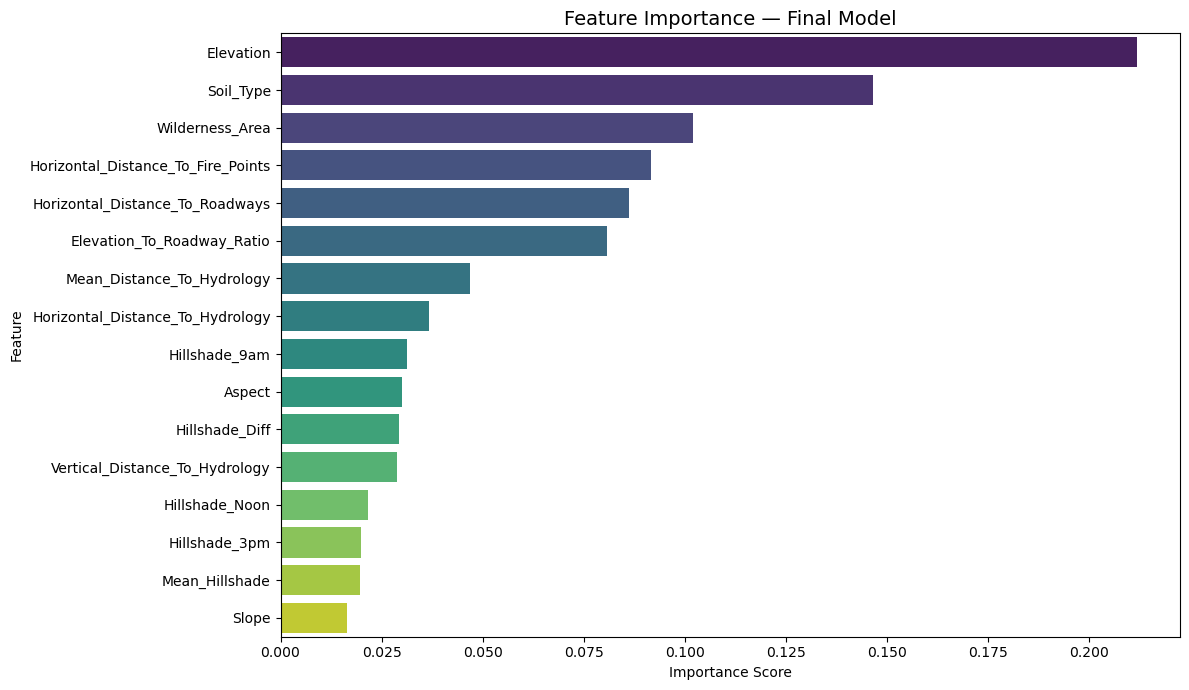


Top 5 Most Important Features:
                               Feature  Importance
0                            Elevation    0.211922
11                           Soil_Type    0.146666
10                     Wilderness_Area    0.101946
9   Horizontal_Distance_To_Fire_Points    0.091621
5      Horizontal_Distance_To_Roadways    0.086166


In [20]:
# Final feature importance chart

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 7))
bars = sns.barplot(x='Importance', y='Feature',
                   data=feature_importance, 
                   palette='viridis')

plt.title('Feature Importance — Final Model', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

#  Complete Project Summary

In [25]:
# Print a complete project summary

print("=" * 60)
print("        ECOTYPE PROJECT — COMPLETE SUMMARY")
print("=" * 60)

print("""
 DATASET
   Source    : UCI / Kaggle Forest Cover Type
   Rows      : 145,891
   Columns   : 13 (+ 4 engineered = 17 total)
   Target    : Cover_Type (7 forest classes)

 DATA CLEANING (Notebook 2)
   Missing values : 0 (none found)
   Duplicates     : 0 (none found)
   Outliers       : Capped using IQR method
   Skewness       : No high skewness found

 EDA FINDINGS (Notebook 3)
   Class imbalance  : Lodgepole Pine = 70.6%
   Top correlation  : Elevation ↔ Roadways (0.69)
   Negative corr    : Hillshade_9am ↔ Hillshade_3pm (-0.81)

 FEATURE ENGINEERING (Notebook 4)
   New features created : 4
   Encoding             : LabelEncoder for categorical cols
   Encoders saved       : 3 pkl files

 MODEL RESULTS (Notebook 5)
   Random Forest      : 99.63%  (BEST)
   Decision Tree      : 99.46%
   KNN                : 99.13%
   XGBoost            : 98.05%
   Logistic Regression: 61.50%

 HYPERPARAMETER TUNING (Notebook 6)
   Method         : RandomizedSearchCV
   CV Mean Score  : 95.61%
   Tuned Accuracy : 99.56%
   Final Decision : Baseline model used (99.63%)

 FINAL MODEL
   Algorithm : Random Forest Classifier
   Accuracy  : 99.63%
   Saved as  : best_model.pkl
""")

print("=" * 60)
print(" PROJECT COMPLETE — READY FOR STREAMLIT APP!")
print("=" * 60)

        ECOTYPE PROJECT — COMPLETE SUMMARY

 DATASET
   Source    : UCI / Kaggle Forest Cover Type
   Rows      : 145,891
   Columns   : 13 (+ 4 engineered = 17 total)
   Target    : Cover_Type (7 forest classes)

 DATA CLEANING (Notebook 2)
   Missing values : 0 (none found)
   Duplicates     : 0 (none found)
   Outliers       : Capped using IQR method
   Skewness       : No high skewness found

 EDA FINDINGS (Notebook 3)
   Class imbalance  : Lodgepole Pine = 70.6%
   Top correlation  : Elevation ↔ Roadways (0.69)
   Negative corr    : Hillshade_9am ↔ Hillshade_3pm (-0.81)

 FEATURE ENGINEERING (Notebook 4)
   New features created : 4
   Encoding             : LabelEncoder for categorical cols
   Encoders saved       : 3 pkl files

 MODEL RESULTS (Notebook 5)
   Random Forest      : 99.63%  (BEST)
   Decision Tree      : 99.46%
   KNN                : 99.13%
   XGBoost            : 98.05%
   Logistic Regression: 61.50%

 HYPERPARAMETER TUNING (Notebook 6)
   Method         : Randomiz

# Verify All Saved Files

In [28]:
# Make sure all required files are saved
# before building the Streamlit app

import os

required_files = [
    '../models/best_model.pkl',
    '../models/le_wilderness.pkl',
    '../models/le_soil.pkl',
    '../models/le_target.pkl',
    '../data/forest_cover_engineered.csv'
]

print("=== CHECKING ALL REQUIRED FILES ===\n")

all_good = True
for filepath in required_files:
    if os.path.exists(filepath):
        size = os.path.getsize(filepath)
        print(f" Found: {filepath} ({size:,} bytes)")
    else:
        print(f" MISSING: {filepath}")
        all_good = False

if all_good:
    print("\n All files present — Ready for Streamlit app!")
else:
    print("\n Some files missing — check previous notebooks!")

=== CHECKING ALL REQUIRED FILES ===

 Found: ../models/best_model.pkl (205,137,233 bytes)
 Found: ../models/le_wilderness.pkl (359 bytes)
 Found: ../models/le_soil.pkl (639 bytes)
 Found: ../models/le_target.pkl (647 bytes)
 Found: ../data/forest_cover_engineered.csv (14,253,773 bytes)

 All files present — Ready for Streamlit app!


## 📝 Summary from Notebook 7

- Loaded final model and all encoders successfully
- Verified all encoders map correctly
- Final model accuracy: 99.63%
- Classification report shows per-class performance
  with actual forest type names
- Confusion matrix confirms model predicts most
  classes perfectly
- Lodgepole Pine is hardest class due to dominance
- Top feature: Elevation (most important predictor)
- All required files verified and present
- Project notebooks: COMPLETE 
- Next and Final Step: Streamlit App Development